# Продуктовый анализ интернет-магазина (продолжение)
## Когорты, RFM-сегментация

**Контекст:** Продолжение анализа британского интернет-магазина.
На первом этапе данные были очищены и подготовлены, посчитаны базовые метрики.

**Цель** — найти точки роста через анализ клиентского поведения.

**Ключевые вопросы:**
1. Как удерживаются клиенты? 
2. Как сегментировать клиентскую базу по ценности (RFM)?

**Инструменты:** Python (Pandas, Matplotlib, Seaborn).
**Данные:** online_retail_clean.csv (результат этапа 01_cleaning_eda).

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = pd.read_csv(r'data_clean.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print(f'Файл агружен!')

Файл агружен!


### Когортный анализ удержания клиентов

In [23]:
# месяц первой покупки для каждого клиента
df['OrderMonth'] = df['InvoiceDate'].dt.to_period('M')
cohort_month = df.groupby('CustomerID')['OrderMonth'].min().reset_index()
cohort_month.columns = ['CustomerID', 'CohortMonth']

df = df.merge(cohort_month, on='CustomerID', how='left')

# считаем порядковый номер месяца от первой покупки
df['CohortIndex'] = (df['OrderMonth'] - df['CohortMonth']).apply(lambda x: x.n)

df[['CustomerID', 'InvoiceDate', 'OrderMonth', 'CohortMonth', 'CohortIndex']].head()

,CustomerID,InvoiceDate,OrderMonth,CohortMonth,CohortIndex
0,17850,2010-12-01 08:26:00,2010-12,2010-12,0
1,17850,2010-12-01 08:26:00,2010-12,2010-12,0
2,17850,2010-12-01 08:26:00,2010-12,2010-12,0
3,17850,2010-12-01 08:26:00,2010-12,2010-12,0
4,17850,2010-12-01 08:26:00,2010-12,2010-12,0


In [24]:
# количество уникальных клиентов в каждой когорте по месяцам
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_table = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# размер когорты (месяц 0)
cohort_size = cohort_table.iloc[:, 0]

retention = cohort_table.divide(cohort_size, axis=0) * 100 # в процентах
retention = retention.round(1)

retention.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,100.0,36.6,32.3,38.4,36.3,39.8,36.3,34.9,35.4,39.5,37.4,50.3,26.6
2011-01,100.0,22.1,26.6,23.0,32.1,28.8,24.7,24.2,30.0,32.6,36.5,11.8,NaN
2011-02,100.0,18.7,18.7,28.4,27.1,24.7,25.3,27.9,24.7,30.5,6.8,NaN,NaN
2011-03,100.0,15.0,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04,100.0,21.3,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN


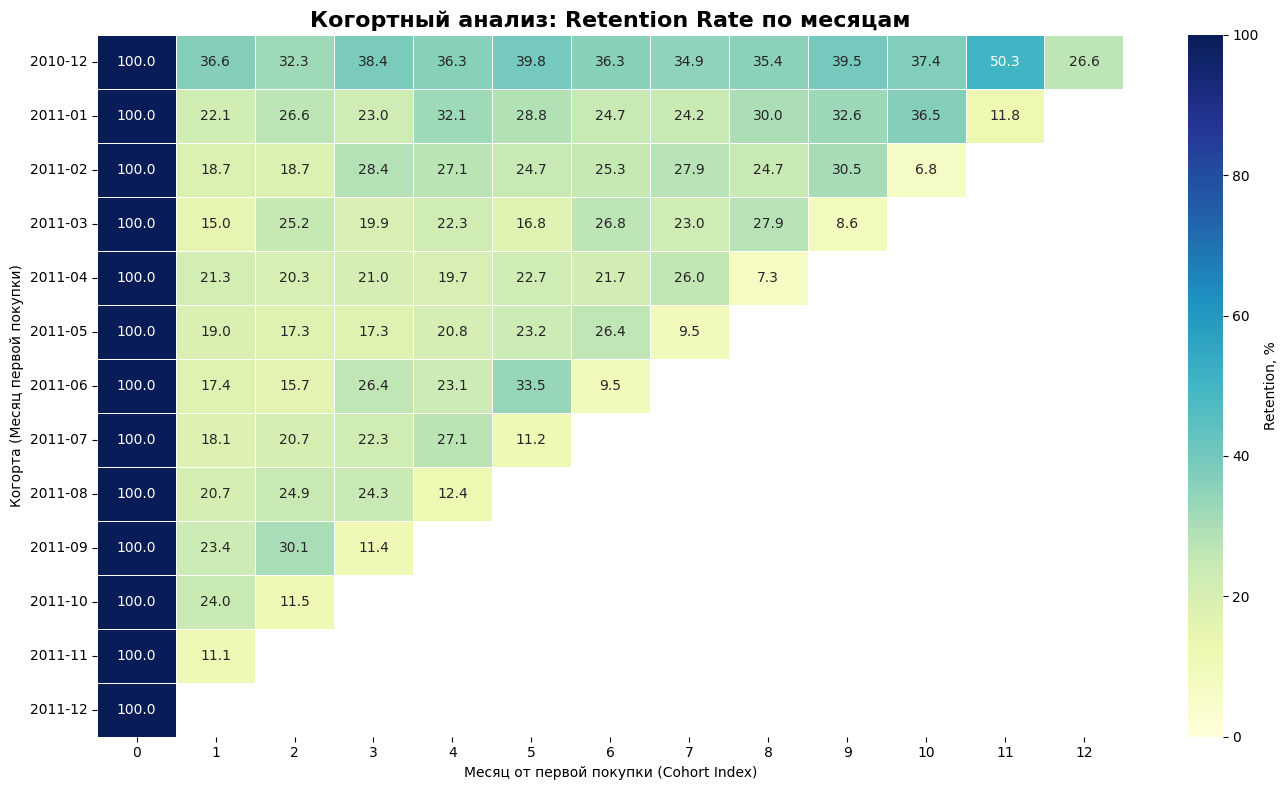

In [25]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    retention,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    vmin=0,
    vmax=100,
    cbar_kws={'label': 'Retention, %'},
    linewidths=0.5,
    linecolor='white'
)
plt.title('Когортный анализ: Retention Rate по месяцам', fontsize=16, fontweight='bold')
plt.xlabel('Месяц от первой покупки (Cohort Index)')
plt.ylabel('Когорта (Месяц первой покупки)')
plt.tight_layout()
plt.show()

In [26]:
retention.mean() # среднии % удержания по месяцам

CohortIndex
0     100.000000
1      20.616667
2      22.118182
3      23.240000
4      24.544444
5      25.087500
6      24.385714
7      24.250000
8      25.060000
9      27.800000
10     26.900000
11     31.050000
12     26.600000
dtype: float64

In [27]:
retention.mean().iloc[1::].mean() # среднее удержание

25.137708934583937

**Наблюдения из тепловой карты:**
- Видно, что клиенты, пришедшие зимой 2010-2011 гг. лояльнее всего. Особенно сильно (даже аномально) это заметно у клиентов пришедших в декабре. Кроме того у декабрьских клиентов высокий retention через 11 месяцев - возможно. 
- В среднем retention сохраняется приблизительно на одном уровне.
- Основной отток происходит после первой покупки.

**Гипотезы:**
- Возможно, клиентов пользовашихся платформой в декабре 2010, удалось таргентно завлечь рекламой распродажи, хотя у январьских и февральских этот показатель ниже. Что говорит, возомжно, о лояльности 'новогодних' покупателей.
- В остальных случаях достаточно низкое удержание клиентов можно попробовать увеличить рассылками на основе данных о покупках, программой лояльности, улучшением приложения и другими методами увеличения конверсии.


### RFM-сегментация клиентской базы

**Что считаем:**
- **Recency (R):** Количество дней с последней покупки клиента.
- **Frequency (F):** Общее количество заказов клиента.
- **Monetary (M):** Суммарная выручка от клиента.

Каждый параметр разбивается на квартили (1-4), где 4 — лучший показатель.

In [28]:
# фиксируем дату «сегодня» как день после последней транзакции в датасете
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [29]:
# делим на квартили (4 — лучший, 1 — худший)
rfm['R_score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1])  # Recency: меньше дней = лучше
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=4, labels=[1, 2, 3, 4])

# комбинированный RFM-сегмент
rfm['RFM_Segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm['RFM_Score'] = rfm[['R_score', 'F_score', 'M_score']].astype(int).sum(axis=1)

rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'RFM_Segment', 'RFM_Score']].head(10)

,CustomerID,Recency,Frequency,Monetary,RFM_Segment,RFM_Score
0,12346,326,1,77183.60,114,6
1,12347,2,7,4310.00,444,12
2,12348,75,4,1797.24,234,9
3,12349,19,1,1757.55,314,8
4,12350,310,1,334.40,112,4
5,12352,36,8,2506.04,344,11
6,12353,204,1,89.00,111,3
7,12354,232,1,1079.40,113,5
8,12355,214,1,459.40,112,4
9,12356,23,3,2811.43,334,10


In [30]:
def segment_customer(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    
    if r == 4 and f == 4 and m == 4:
        return 'Чемпионы'
    elif f >= 3 and m >= 3:
        return 'Лояльные'
    elif r >= 3 and f <= 2:
        return 'Новые'
    elif r <= 2 and f >= 3:
        return 'Спящие'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Потерянные'
    else:
        return 'Средние'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

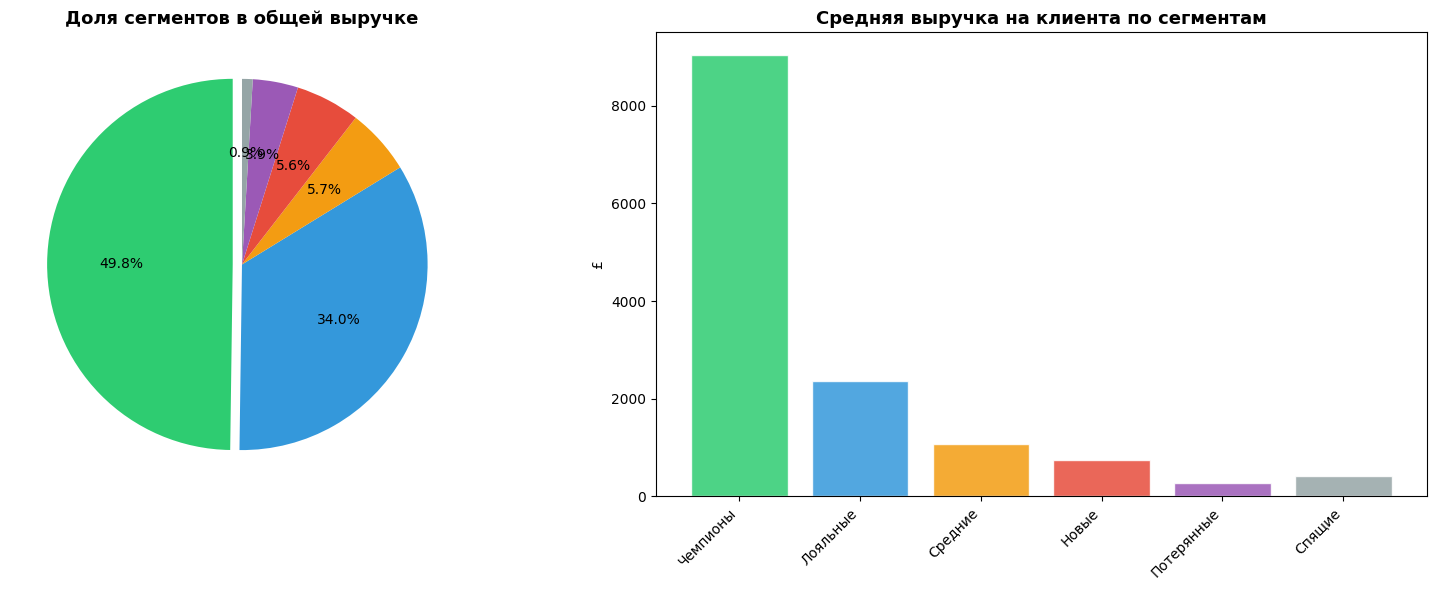

In [31]:
segment_stats = rfm.groupby('Segment').agg(
    Customers=('CustomerID', 'nunique'),
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    TotalRevenue=('Monetary', 'sum')
).sort_values('TotalRevenue', ascending=False)

# Доля в выручке
segment_stats['RevenueShare'] = (segment_stats['TotalRevenue'] / segment_stats['TotalRevenue'].sum() * 100).round(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart — доля в выручке
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6', '#95a5a6']
ax1.pie(segment_stats['TotalRevenue'], autopct='%1.1f%%', 
        colors=colors, startangle=90, explode=(0.05, 0, 0, 0, 0, 0))
ax1.set_title('Доля сегментов в общей выручке', fontsize=13, fontweight='bold')

# Bar chart — средний чек по сегменту
ax2.bar(segment_stats.index, segment_stats['AvgMonetary'], color=colors, alpha=0.85, edgecolor='white')
ax2.set_title('Средняя выручка на клиента по сегментам', fontsize=13, fontweight='bold')
ax2.set_ylabel('£')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [32]:
segment_stats['CustomersShare'] = round(segment_stats['Customers'] / segment_stats['Customers'].sum() * 100, 1)
segment_stats

,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue,RevenueShare,CustomersShare
Segment,,,,,,,
Чемпионы,489,7.419223,15.525562,9047.798793,4424373.610,49.8,11.3
Лояльные,1277,52.158183,5.382929,2364.997871,3020102.281,34.0,29.4
Средние,472,93.010593,2.205508,1079.925002,509724.601,5.7,10.9
Новые,665,25.251128,1.448120,751.284767,499604.370,5.6,15.3
Потерянные,1238,194.821486,1.186591,283.497893,350970.391,3.9,28.5
Спящие,197,148.766497,3.010152,418.444878,82433.641,0.9,4.5


**Ключевые наблюдения:**
- Сегмент «Чемпионы» — 11,3% клиентов, но 49,8% выручки.
- Сегмент «Потерянные» — 28,5% клиентов.
- Средний чек «Лояльных» выше, чем у «Новых» — признак того, что клиенты осторожны по началу и ещё знакомятся с площадкой.

**Рекомендации:**
- «Спящие»: запустить кампанию с промокодом.
- «Чемпионы»: программа лояльности, ранний доступ к новинкам, VIP-подход.
- «Новые»: стараемся мотивировать покупать ещё больше, чтобы рос средний чек - серия приветственных писем с рекомендациями товаров.

## Итоги анализа

### Ключевые инсайты
1. **Удержание:** Основной отток клиентов происходит после первой покупки.
   Средний Retention на 2-й месяц — всего 20%.
2. **Сегментация:** «Чемпионы» (11,3% клиентов) генерируют 49,8% выручки.
   «Спящие» — потенциально неиспользованный резерв для реактивации.


### Рекомендации продукту
| Приоритет | Рекомендация | Ожидаемый эффект |
|-----------|-------------|------------------|
| Высокий | Запустить рассылки после первой покупки | Рост Retention на 2-й месяц |
| Средний | Реактивировать «Спящих» через промокоды | рост GMV |
| Низкий | Мотивировать «Новых» на покупки | Рост среднего чека и GMV |


### Так же рекомендуется:
1. Мотивировать клиентов регистрироваться на платформе, чтобы было больше данных для анализа.
2. Детально проанализировать клиентов пришедших в декабре 2010 года, чтобы понять их паттерн поведения и использовать это в будущем. 
3. Проанализировать и понять как на поведение клиентов влияет сезонность.
4. Проанализировать отдельно осеннюю рекламную кампанию.
